# Data Exploration and Visualization - Capstone
**Exploratory Analysis and Visualization of OpenStreetMap Facility Data**  
Units 1-5 | Dataset: OSM facility summary by country | Author: Anushya

In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta, gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 10})
sns.set_style("whitegrid")
FIG = "figures/"; R = {}
def save(name):
    plt.tight_layout(); plt.savefig(FIG + name, bbox_inches="tight"); plt.show()

## Unit 1

In [2]:
df = pd.read_csv("data/osm_facilities.csv", encoding="utf-8")
R["shape"] = list(df.shape)
R["missing"] = df.isna().sum().to_dict()
R["dups"] = int(df.duplicated().sum())
R["missing_country"] = df[df.country_iso3.isna()].country.tolist()
df["country_iso3"] = df["country_iso3"].fillna("XKX")        # Kosovo (user-assigned code XKX)
num = ["osm_facilities", "with_name", "with_operator", "with_city", "with_footprint"]
for c in ["name", "operator", "city", "footprint"]:
    df[f"with_{c}_pct"] = 100 * df[f"with_{c}"] / df["osm_facilities"]
df["log_facilities"] = np.log1p(df["osm_facilities"])
df["size_class"] = pd.cut(df.osm_facilities, [0, 5, 25, 100, 5000],
                          labels=["Small (1-5)", "Medium (6-25)", "Large (26-100)", "Very large (>100)"])
cont = df.groupby("continent")[num].sum()
cont["countries"] = df.groupby("continent").size()
for c in ["name", "operator", "city", "footprint"]:
    cont[f"{c}_pct"] = 100 * cont[f"with_{c}"] / cont["osm_facilities"]
cont = cont.sort_values("osm_facilities", ascending=False)
R["continent"] = cont.round(2).reset_index().to_dict("records")
R["totals"] = df[num].sum().to_dict()
tot = df[num].sum()
R["overall_pct"] = {c: round(100 * tot[f"with_{c}"] / tot["osm_facilities"], 2) for c in ["name", "operator", "city", "footprint"]}
sub = df.groupby("subregion")[num].sum().sort_values("osm_facilities", ascending=False)
R["subregion_top"] = sub.head(8).reset_index().to_dict("records")
R["asia_n"] = int((df.continent == "Asia").sum())
R["india"] = df[df.country == "India"][num].iloc[0].to_dict()
R["top10"] = df.nlargest(10, "osm_facilities")[["country", "osm_facilities", "with_footprint"]].to_dict("records")
R["zero_countries"] = {c: int((df[f"with_{c}"] == 0).sum()) for c in ["name", "operator", "city", "footprint"]}
s, t = tot["with_footprint"], tot["osm_facilities"]
post = beta(s + 1, t - s + 1)
R["bayes"] = {"s": int(s), "f": int(t - s), "mean": post.mean() * 100, "lo": post.ppf(.025) * 100, "hi": post.ppf(.975) * 100}
p = s / t; se = np.sqrt(p * (1 - p) / t)
R["classical"] = {"p": p * 100, "lo": (p - 1.96 * se) * 100, "hi": (p + 1.96 * se) * 100}

## Unit 2

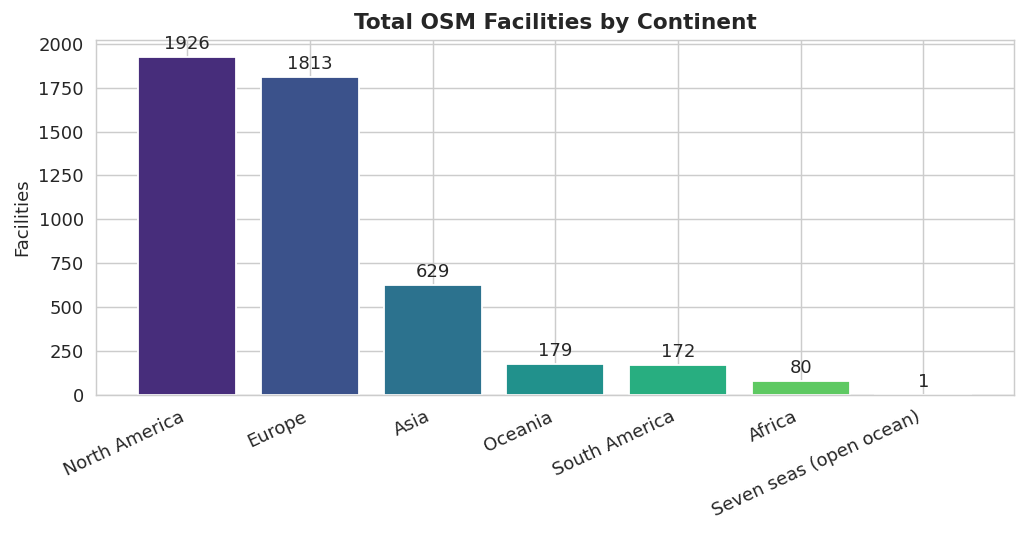

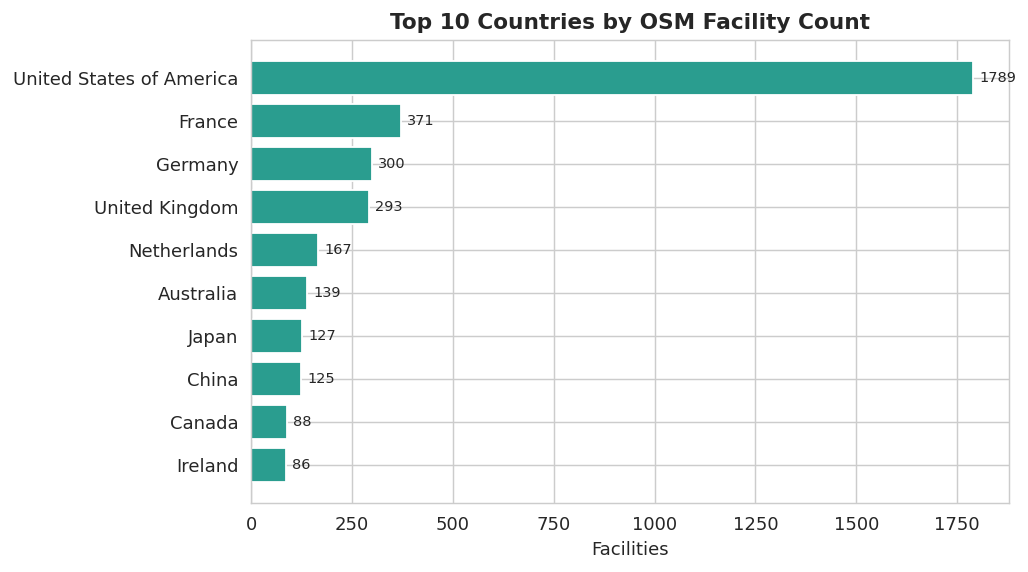

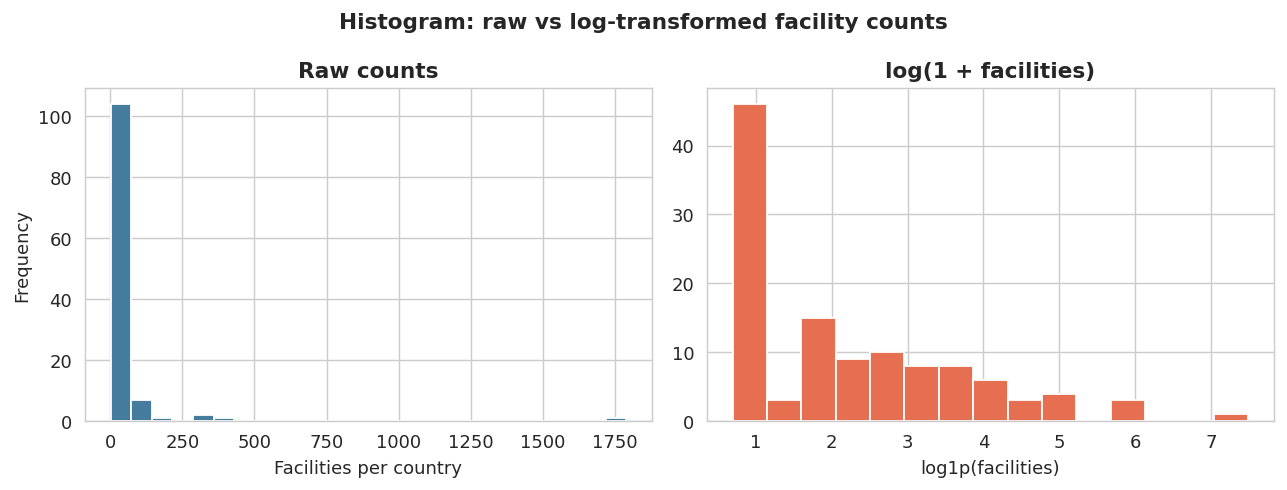

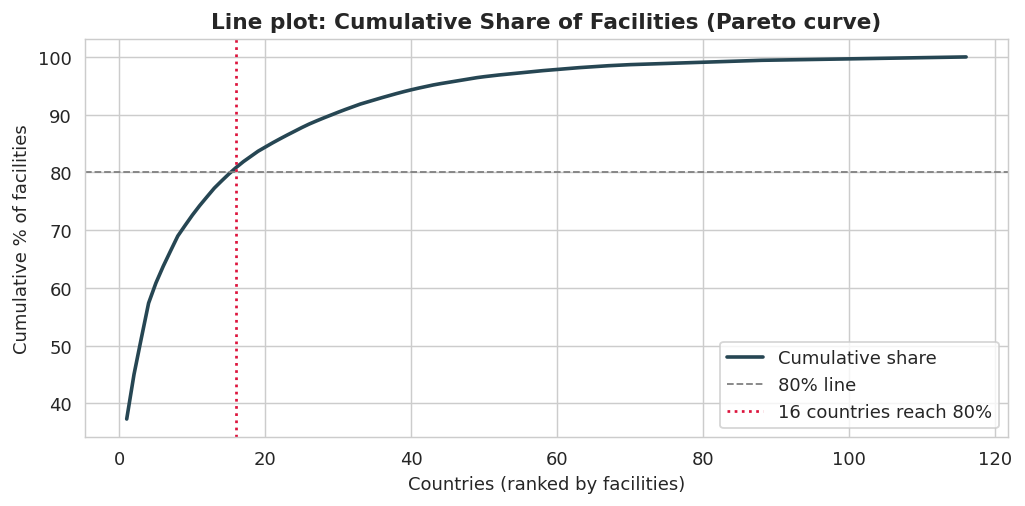

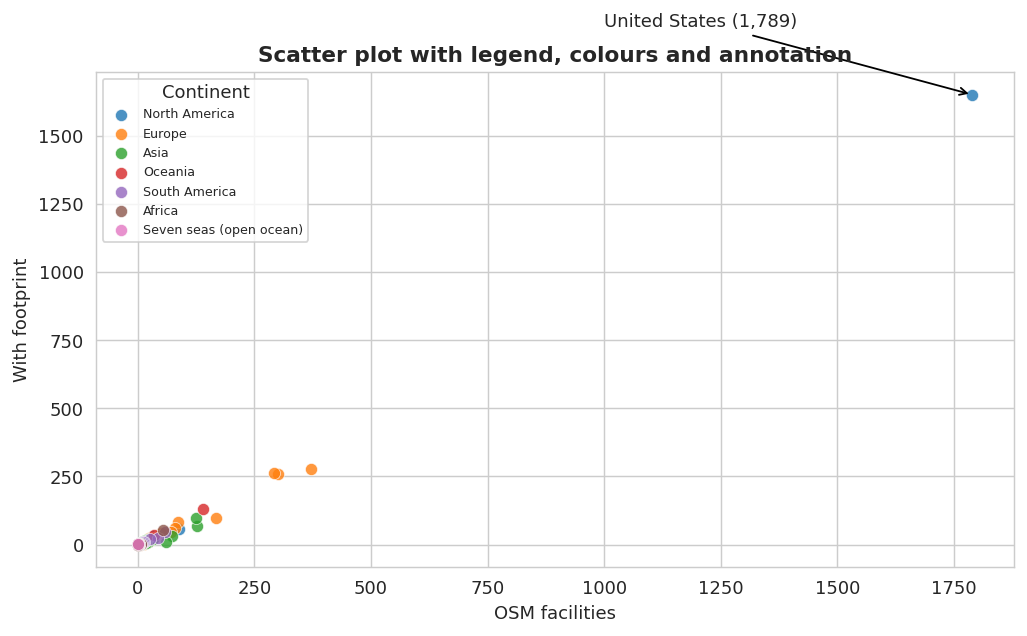

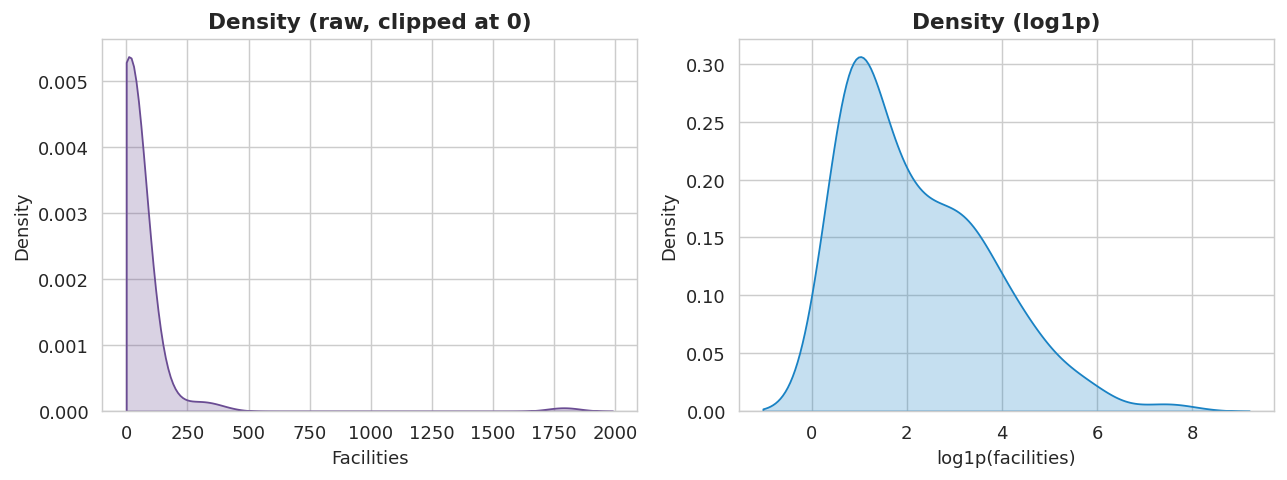

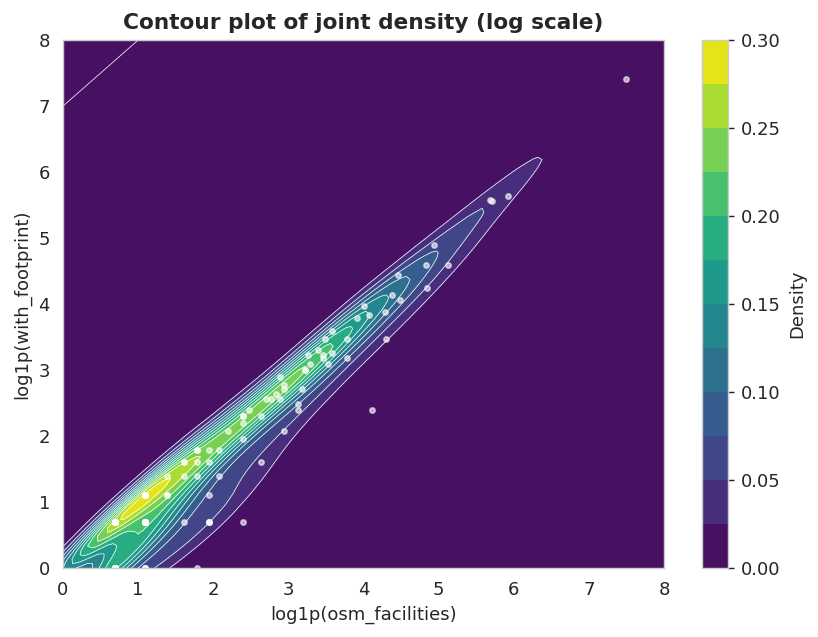

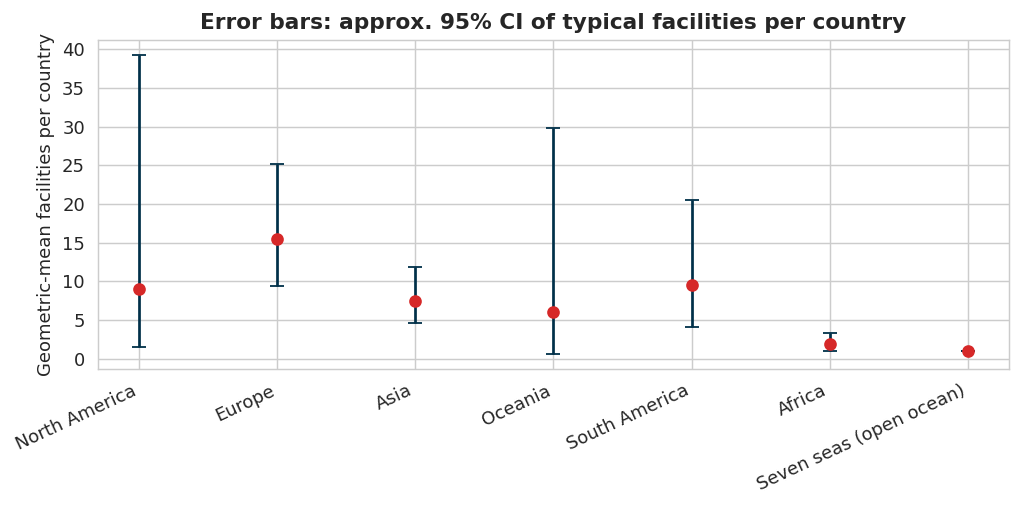

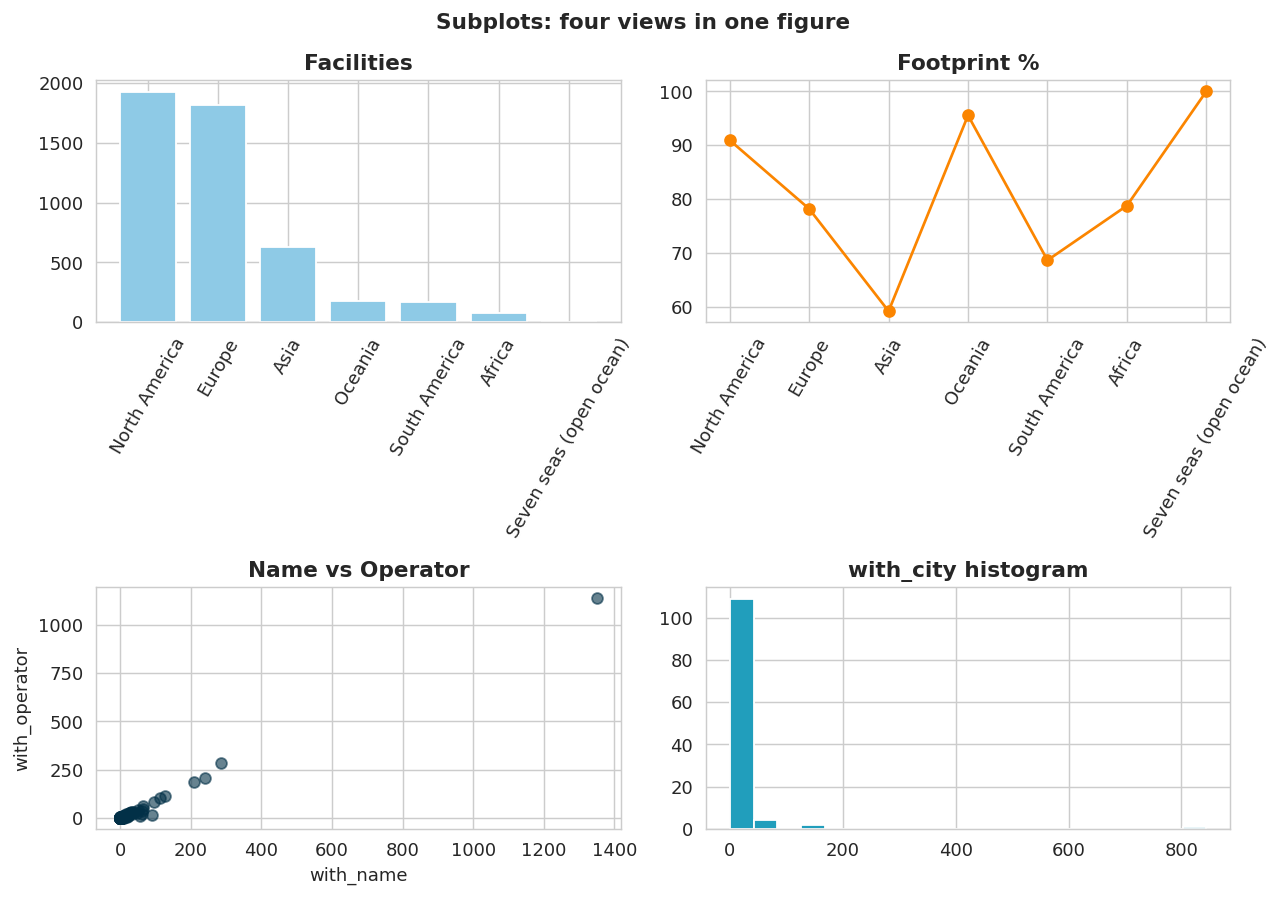

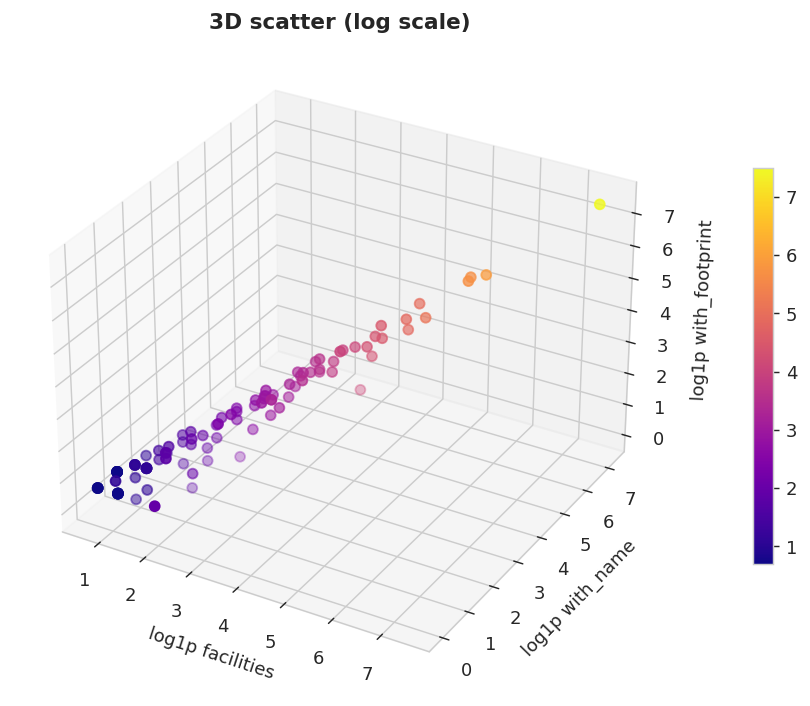

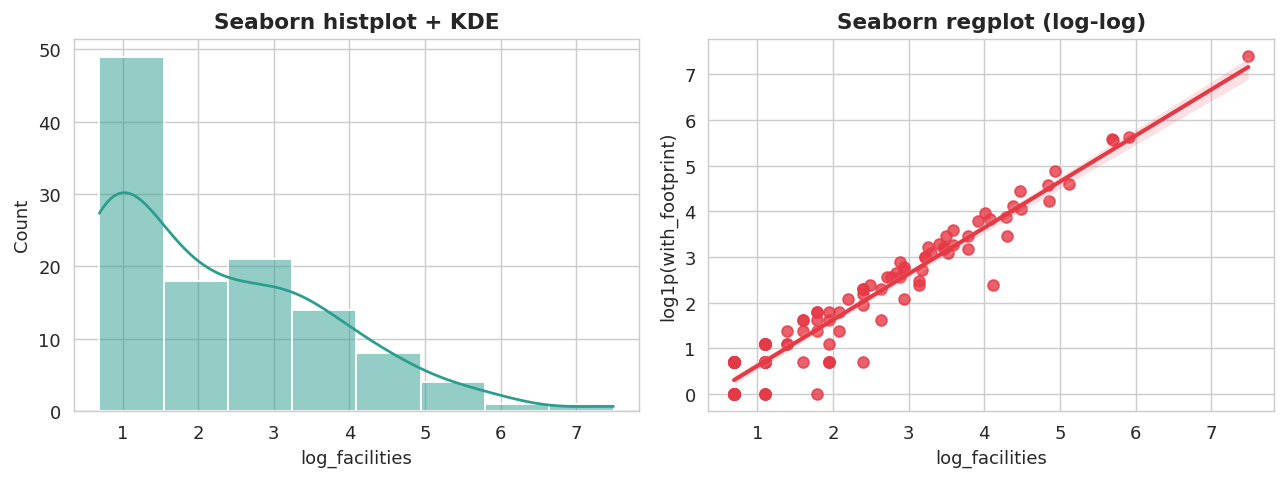

'/home/claude/work/interactive/bokeh_facilities_vs_footprint.html'

In [3]:
order = cont.index.tolist()
fig, ax = plt.subplots(figsize=(8, 4.2))
b = ax.bar(order, cont.osm_facilities, color=sns.color_palette("viridis", len(order)))
ax.bar_label(b, padding=2); ax.set_title("Total OSM Facilities by Continent"); ax.set_ylabel("Facilities")
plt.xticks(rotation=25, ha="right"); save("01_facilities_by_continent.png")

top = df.nlargest(10, "osm_facilities").iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top.country, top.osm_facilities, color="#2a9d8f"); ax.set_title("Top 10 Countries by OSM Facility Count")
for i, v in enumerate(top.osm_facilities): ax.text(v + 15, i, str(v), va="center", fontsize=8)
ax.set_xlabel("Facilities"); save("02_top10_countries.png")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].hist(df.osm_facilities, bins=25, color="#457b9d", edgecolor="white"); ax[0].set_title("Raw counts"); ax[0].set_xlabel("Facilities per country"); ax[0].set_ylabel("Frequency")
ax[1].hist(df.log_facilities, bins=15, color="#e76f51", edgecolor="white"); ax[1].set_title("log(1 + facilities)"); ax[1].set_xlabel("log1p(facilities)")
fig.suptitle("Histogram: raw vs log-transformed facility counts", fontweight="bold"); save("03_histograms_raw_log.png")

srt = df.sort_values("osm_facilities", ascending=False).reset_index(drop=True)
cum = srt.osm_facilities.cumsum() / srt.osm_facilities.sum() * 100
R["cum"] = {"top1": cum[0], "top5": cum[4], "top10": cum[9], "top20": cum[19], "n50": int((cum < 50).sum() + 1), "n80": int((cum < 80).sum() + 1)}
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum) + 1), cum, lw=2, color="#264653", label="Cumulative share")
ax.axhline(80, ls="--", color="grey", lw=1, label="80% line"); ax.axvline(R["cum"]["n80"], ls=":", color="crimson", label=f"{R['cum']['n80']} countries reach 80%")
ax.set_xlabel("Countries (ranked by facilities)"); ax.set_ylabel("Cumulative % of facilities"); ax.set_title("Line plot: Cumulative Share of Facilities (Pareto curve)"); ax.legend(); save("04_cumulative_line.png")

fig, ax = plt.subplots(figsize=(8, 5))
pal = dict(zip(order, sns.color_palette("tab10", len(order))))
for c in order:
    d = df[df.continent == c]; ax.scatter(d.osm_facilities, d.with_footprint, s=45, alpha=.8, label=c, color=pal[c], edgecolor="white", lw=.4)
us = df[df.country_iso2 == "US"].iloc[0]
ax.annotate("United States (1,789)", (us.osm_facilities, us.with_footprint), xytext=(1000, 1900), arrowprops=dict(arrowstyle="->", color="black"))
ax.set_xlabel("OSM facilities"); ax.set_ylabel("With footprint"); ax.set_title("Scatter plot with legend, colours and annotation"); ax.legend(fontsize=7, title="Continent"); save("05_scatter_annotated.png")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
sns.kdeplot(df.osm_facilities, fill=True, ax=ax[0], color="#6a4c93", clip=(0, None)); ax[0].set_title("Density (raw, clipped at 0)"); ax[0].set_xlabel("Facilities")
sns.kdeplot(df.log_facilities, fill=True, ax=ax[1], color="#1982c4"); ax[1].set_title("Density (log1p)"); ax[1].set_xlabel("log1p(facilities)")
save("06_density_plots.png")

x, y = df.log_facilities.values, np.log1p(df.with_footprint.values)
kde = gaussian_kde(np.vstack([x, y])); xx, yy = np.mgrid[0:8:120j, 0:8:120j]
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(6.5, 5))
cs = ax.contourf(xx, yy, zz, levels=12, cmap="viridis"); ax.contour(xx, yy, zz, levels=12, colors="white", linewidths=.4)
ax.scatter(x, y, s=8, color="white", alpha=.6); fig.colorbar(cs, label="Density")
ax.set_xlabel("log1p(osm_facilities)"); ax.set_ylabel("log1p(with_footprint)"); ax.set_title("Contour plot of joint density (log scale)"); save("07_contour.png")

rows = []
for c in order:
    v = df[df.continent == c].log_facilities
    m = v.mean(); ci = 1.96 * v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0
    rows.append((c, np.expm1(m), np.expm1(m - ci), np.expm1(m + ci)))
eb = pd.DataFrame(rows, columns=["c", "m", "lo", "hi"]); R["errbar"] = eb.round(2).to_dict("records")
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(range(len(eb)), eb.m, yerr=[eb.m - eb.lo, eb.hi - eb.m], fmt="o", capsize=4, color="#d62828", ecolor="#003049")
ax.set_xticks(range(len(eb))); ax.set_xticklabels(eb.c, rotation=25, ha="right"); ax.set_ylabel("Geometric-mean facilities per country")
ax.set_title("Error bars: approx. 95% CI of typical facilities per country"); save("08_errorbars.png")

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
axs[0, 0].bar(order, cont.osm_facilities, color="#8ecae6"); axs[0, 0].set_title("Facilities"); axs[0, 0].tick_params(axis="x", rotation=60)
axs[0, 1].plot(order, cont.footprint_pct, marker="o", color="#fb8500"); axs[0, 1].set_title("Footprint %"); axs[0, 1].tick_params(axis="x", rotation=60)
axs[1, 0].scatter(df.with_name, df.with_operator, alpha=.6, color="#023047"); axs[1, 0].set_title("Name vs Operator"); axs[1, 0].set_xlabel("with_name"); axs[1, 0].set_ylabel("with_operator")
axs[1, 1].hist(df.with_city, bins=20, color="#219ebc"); axs[1, 1].set_title("with_city histogram")
fig.suptitle("Subplots: four views in one figure", fontweight="bold"); save("09_subplots.png")

fig = plt.figure(figsize=(7, 5.5)); ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(df.log_facilities, np.log1p(df.with_name), np.log1p(df.with_footprint), c=df.log_facilities, cmap="plasma", s=30)
ax.set_xlabel("log1p facilities"); ax.set_ylabel("log1p with_name"); ax.set_zlabel("log1p with_footprint"); ax.set_title("3D scatter (log scale)"); fig.colorbar(sc, shrink=.6, pad=.1)
save("10_3d_scatter.png")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
sns.histplot(df.log_facilities, kde=True, ax=ax[0], color="#2a9d8f"); ax[0].set_title("Seaborn histplot + KDE")
sns.regplot(x=df.log_facilities, y=np.log1p(df.with_footprint), ax=ax[1], color="#e63946"); ax[1].set_title("Seaborn regplot (log-log)"); ax[1].set_ylabel("log1p(with_footprint)")
save("11_seaborn.png")

import plotly.express as px
fig = px.scatter(df, x="osm_facilities", y="with_footprint", hover_name="country", size="with_name", color="continent", log_x=True, log_y=True,
                 title="Facilities vs Footprint (interactive, log axes)")
fig.write_html("interactive/plotly_facilities_vs_footprint.html")
try:
    fig.update_layout(width=900, height=520); fig.write_image(FIG + "12_plotly_static.png", scale=2); R["plotly_png"] = True
except Exception as e:
    R["plotly_png"] = False
from bokeh.plotting import figure, output_file, save as bsave
from bokeh.models import HoverTool, ColumnDataSource
output_file("interactive/bokeh_facilities_vs_footprint.html")
src = ColumnDataSource(df[["country", "osm_facilities", "with_footprint", "continent"]])
p_ = figure(title="Facilities vs Footprint (Bokeh)", x_axis_type="log", y_axis_type="log", width=800, height=450)
p_.scatter("osm_facilities", "with_footprint", source=src, size=8, alpha=.7); p_.add_tools(HoverTool(tooltips=[("Country", "@country"), ("Facilities", "@osm_facilities"), ("Footprint", "@with_footprint")]))
bsave(p_)

## Unit 3

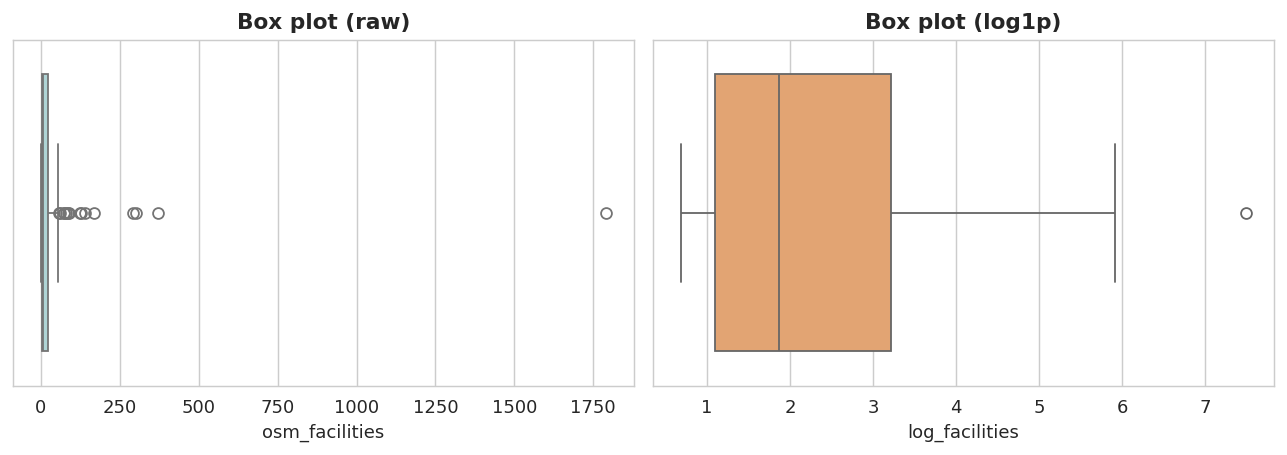

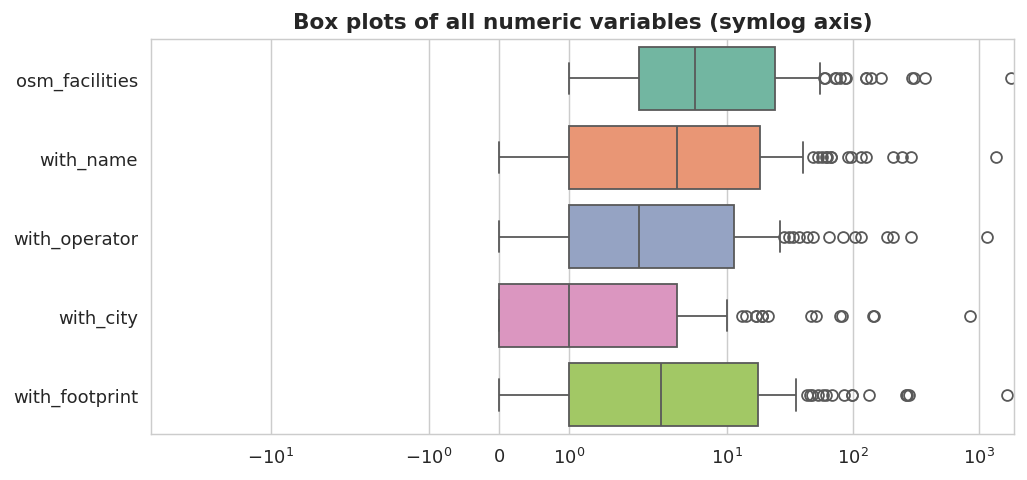

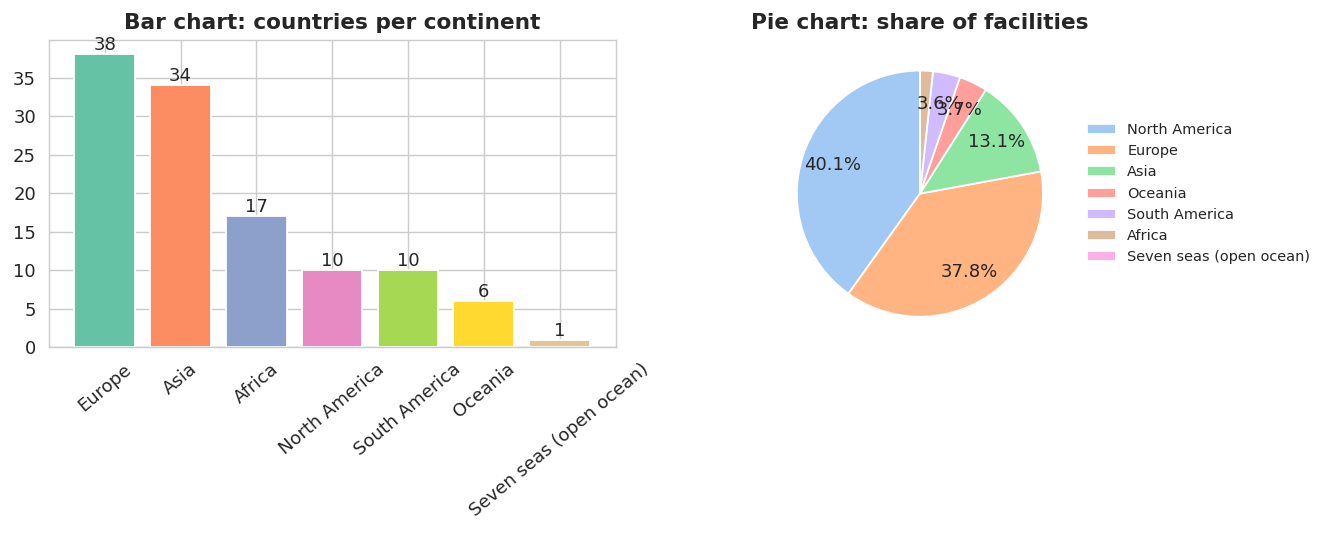

In [4]:
s_ = df.osm_facilities
q1, q3 = s_.quantile([.25, .75]); iqr = q3 - q1; fence = q3 + 1.5 * iqr
out = df[s_ > fence]
R["uni"] = {"mean": s_.mean(), "median": s_.median(), "std": s_.std(), "q1": q1, "q3": q3, "iqr": iqr, "fence": fence, "min": s_.min(), "max": s_.max(),
            "skew": s_.skew(), "kurt": s_.kurt(), "cv": s_.std() / s_.mean() * 100, "n_out": len(out), "out_names": out.nlargest(5, "osm_facilities").country.tolist(),
            "skew_log": df.log_facilities.skew(), "mode": float(s_.mode()[0]), "var": s_.var(), "p90": s_.quantile(.9), "p99": s_.quantile(.99), "range": s_.max() - s_.min()}
desc = df[num].describe().T.round(2); R["describe"] = desc.reset_index().to_dict("records")
R["skew_all"] = df[num].skew().round(2).to_dict()
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
sns.boxplot(x=df.osm_facilities, ax=ax[0], color="#a8dadc"); ax[0].set_title("Box plot (raw)")
sns.boxplot(x=df.log_facilities, ax=ax[1], color="#f4a261"); ax[1].set_title("Box plot (log1p)"); save("13_boxplots.png")
fig, ax = plt.subplots(figsize=(8, 3.8)); sns.boxplot(data=df[num], orient="h", palette="Set2", ax=ax); ax.set_xscale("symlog"); ax.set_title("Box plots of all numeric variables (symlog axis)"); save("14_box_all_numeric.png")

vc = df.continent.value_counts(); R["vc"] = vc.to_dict()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].bar(vc.index, vc.values, color=sns.color_palette("Set2", len(vc))); ax[0].set_title("Bar chart: countries per continent"); ax[0].tick_params(axis="x", rotation=40); ax[0].bar_label(ax[0].containers[0])
sh = cont.osm_facilities
ax[1].pie(sh, autopct=lambda p: f"{p:.1f}%" if p >= 3 else "", startangle=90, colors=sns.color_palette("pastel"), wedgeprops=dict(edgecolor="white"), pctdistance=.75)
ax[1].legend(sh.index, loc="center left", bbox_to_anchor=(1, .5), fontsize=8, frameon=False); ax[1].set_title("Pie chart: share of facilities")
save("15_bar_pie.png")
R["share"] = (cont.osm_facilities / cont.osm_facilities.sum() * 100).round(2).to_dict()

## Unit 4

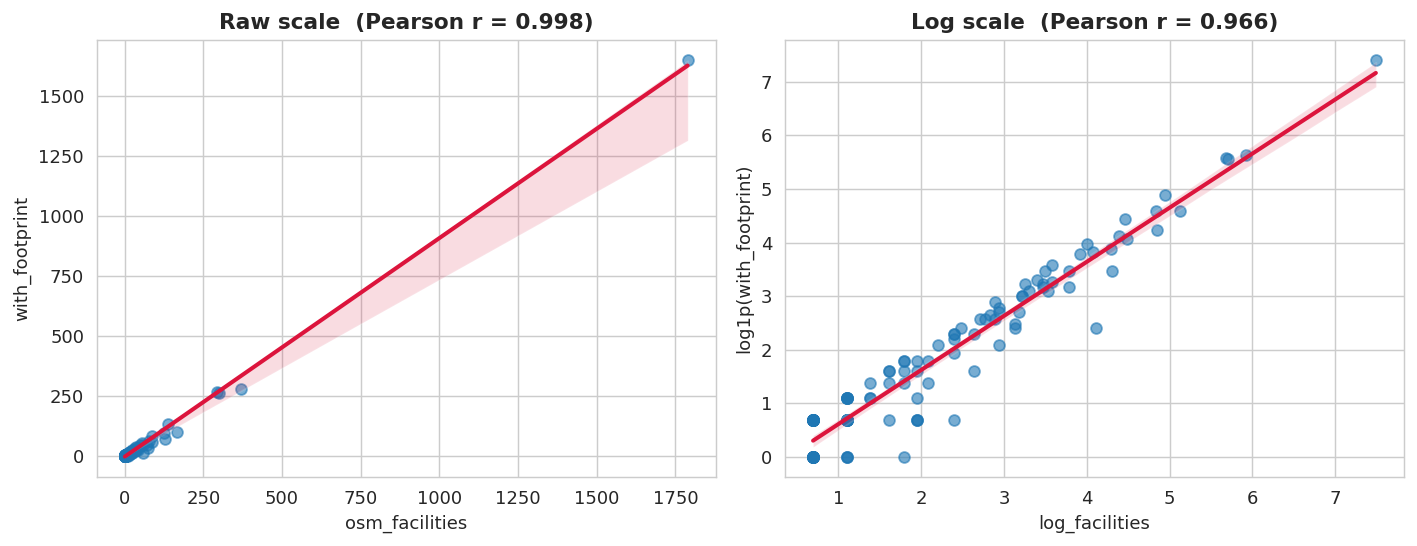

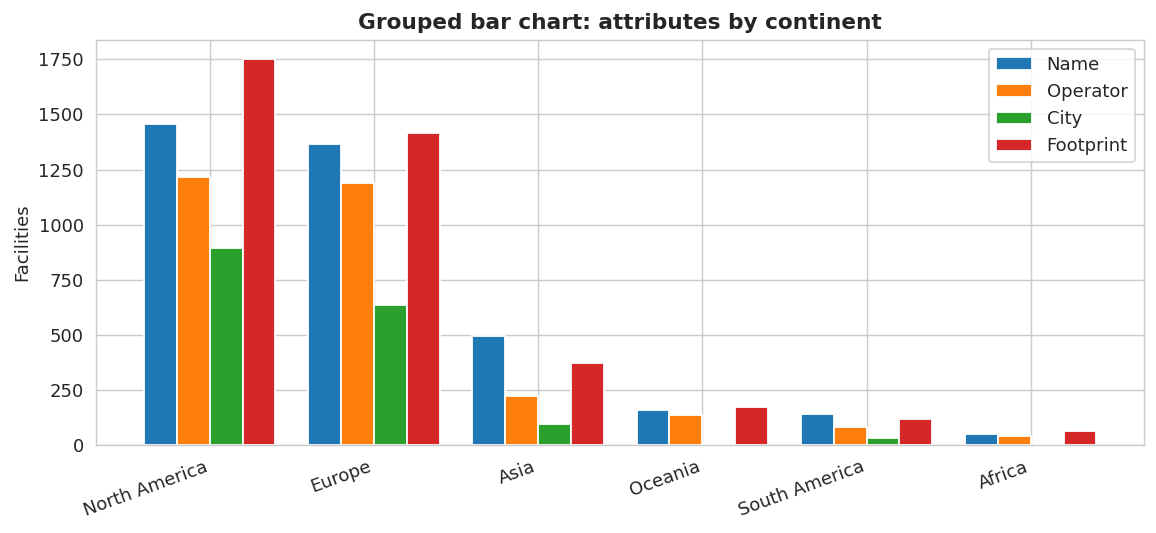

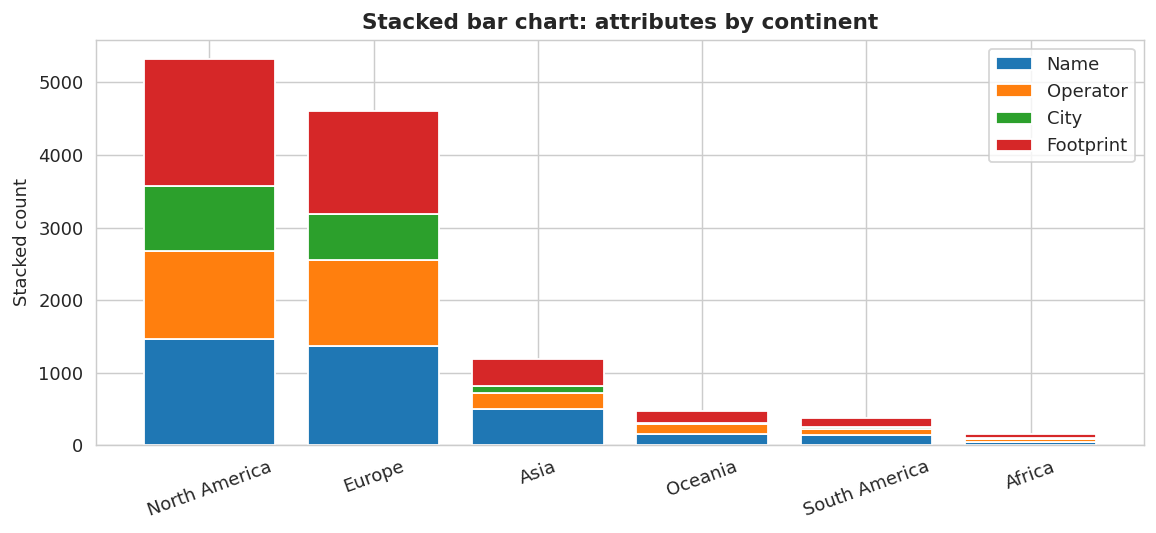

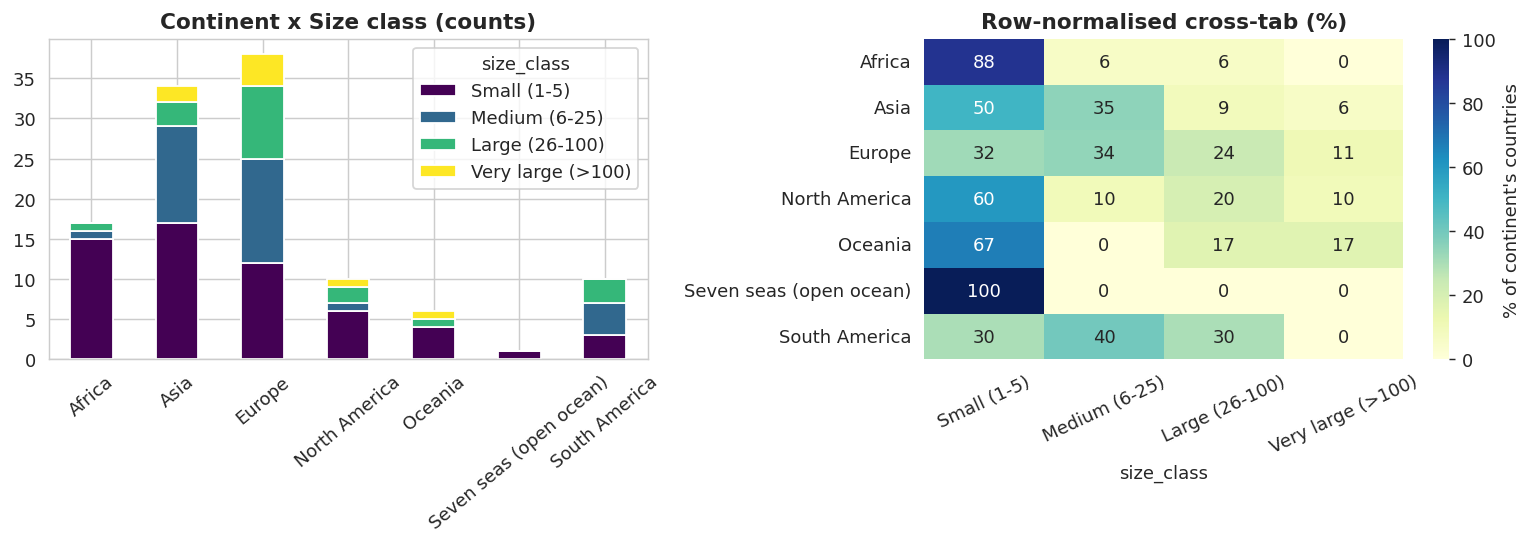

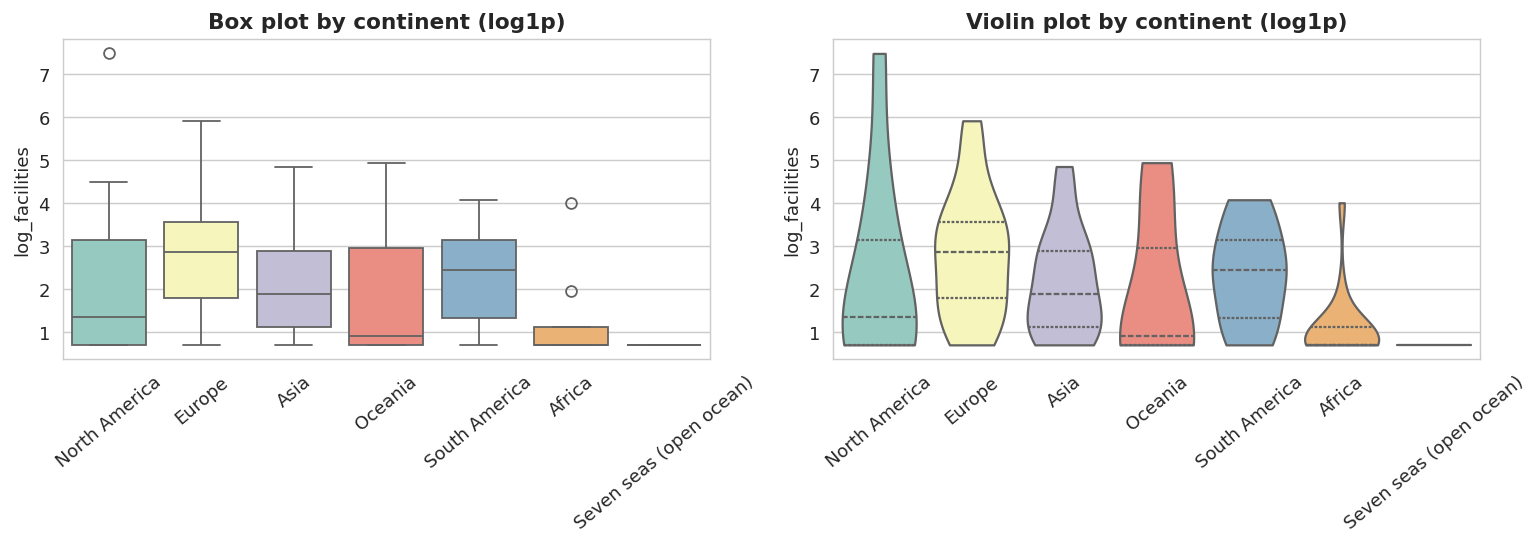

In [5]:
pr = stats.pearsonr(df.osm_facilities, df.with_footprint); sp = stats.spearmanr(df.osm_facilities, df.with_footprint)
R["corr"] = {"pearson": pr[0], "p_p": pr[1], "spearman": sp[0], "p_s": sp[1]}
pr_l = stats.pearsonr(df.log_facilities, np.log1p(df.with_footprint)); R["corr"]["pearson_log"] = pr_l[0]
sl = stats.linregress(df.osm_facilities, df.with_footprint); R["linreg"] = {"slope": sl.slope, "intercept": sl.intercept, "r2": sl.rvalue ** 2}
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
sns.regplot(data=df, x="osm_facilities", y="with_footprint", ax=ax[0], scatter_kws=dict(alpha=.6), line_kws=dict(color="crimson")); ax[0].set_title(f"Raw scale  (Pearson r = {pr[0]:.3f})")
sns.regplot(x=df.log_facilities, y=np.log1p(df.with_footprint), ax=ax[1], scatter_kws=dict(alpha=.6), line_kws=dict(color="crimson")); ax[1].set_title(f"Log scale  (Pearson r = {pr_l[0]:.3f})"); ax[1].set_ylabel("log1p(with_footprint)")
save("16_scatter_correlation.png")

x = cont.drop("Seven seas (open ocean)")
fig, ax = plt.subplots(figsize=(9, 4.2)); w = .2; idx = np.arange(len(x))
for i, (c, col) in enumerate(zip(["with_name", "with_operator", "with_city", "with_footprint"], ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])):
    ax.bar(idx + (i - 1.5) * w, x[c], w, label=c.replace("with_", "").title(), color=col)
ax.set_xticks(idx); ax.set_xticklabels(x.index, rotation=20, ha="right"); ax.legend(); ax.set_ylabel("Facilities"); ax.set_title("Grouped bar chart: attributes by continent"); save("17_grouped_bar.png")
fig, ax = plt.subplots(figsize=(9, 4.2)); bot = np.zeros(len(x))
for c, col in zip(["with_name", "with_operator", "with_city", "with_footprint"], ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]):
    ax.bar(x.index, x[c], bottom=bot, label=c.replace("with_", "").title(), color=col); bot += x[c].values
ax.legend(); ax.set_title("Stacked bar chart: attributes by continent"); ax.tick_params(axis="x", rotation=20); ax.set_ylabel("Stacked count"); save("18_stacked_bar.png")

ct = pd.crosstab(df.continent, df.size_class); R["crosstab"] = ct.reset_index().to_dict("records")
chi = stats.chi2_contingency(ct.drop("Seven seas (open ocean)")); R["chi2"] = {"chi2": chi[0], "p": chi[1], "dof": chi[2]}
ctn = pd.crosstab(df.continent, df.size_class, normalize="index") * 100
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ct.plot(kind="bar", stacked=True, ax=ax[0], colormap="viridis"); ax[0].set_title("Continent x Size class (counts)"); ax[0].tick_params(axis="x", rotation=40); ax[0].set_xlabel("")
sns.heatmap(ctn.round(0), annot=True, fmt=".0f", cmap="YlGnBu", ax=ax[1], cbar_kws=dict(label="% of continent's countries")); ax[1].set_title("Row-normalised cross-tab (%)"); ax[1].set_ylabel(""); ax[1].tick_params(axis="x", rotation=25)
save("19_categorical_crosstab.png")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
sns.boxplot(data=df, x="continent", y="log_facilities", order=order, ax=ax[0], palette="Set3"); ax[0].set_title("Box plot by continent (log1p)"); ax[0].tick_params(axis="x", rotation=40); ax[0].set_xlabel("")
sns.violinplot(data=df, x="continent", y="log_facilities", order=order, ax=ax[1], palette="Set3", inner="quartile", cut=0); ax[1].set_title("Violin plot by continent (log1p)"); ax[1].tick_params(axis="x", rotation=40); ax[1].set_xlabel("")
save("20_box_violin.png")
grp = [g.log_facilities.values for n, g in df.groupby("continent") if len(g) > 1]
kw = stats.kruskal(*grp); an = stats.f_oneway(*grp); R["kruskal"] = {"H": kw[0], "p": kw[1]}; R["anova"] = {"F": an[0], "p": an[1]}
med = df.groupby("continent").osm_facilities.agg(["count", "median", "mean", "max"]).loc[order].round(1); R["med"] = med.reset_index().to_dict("records")

## Unit 5

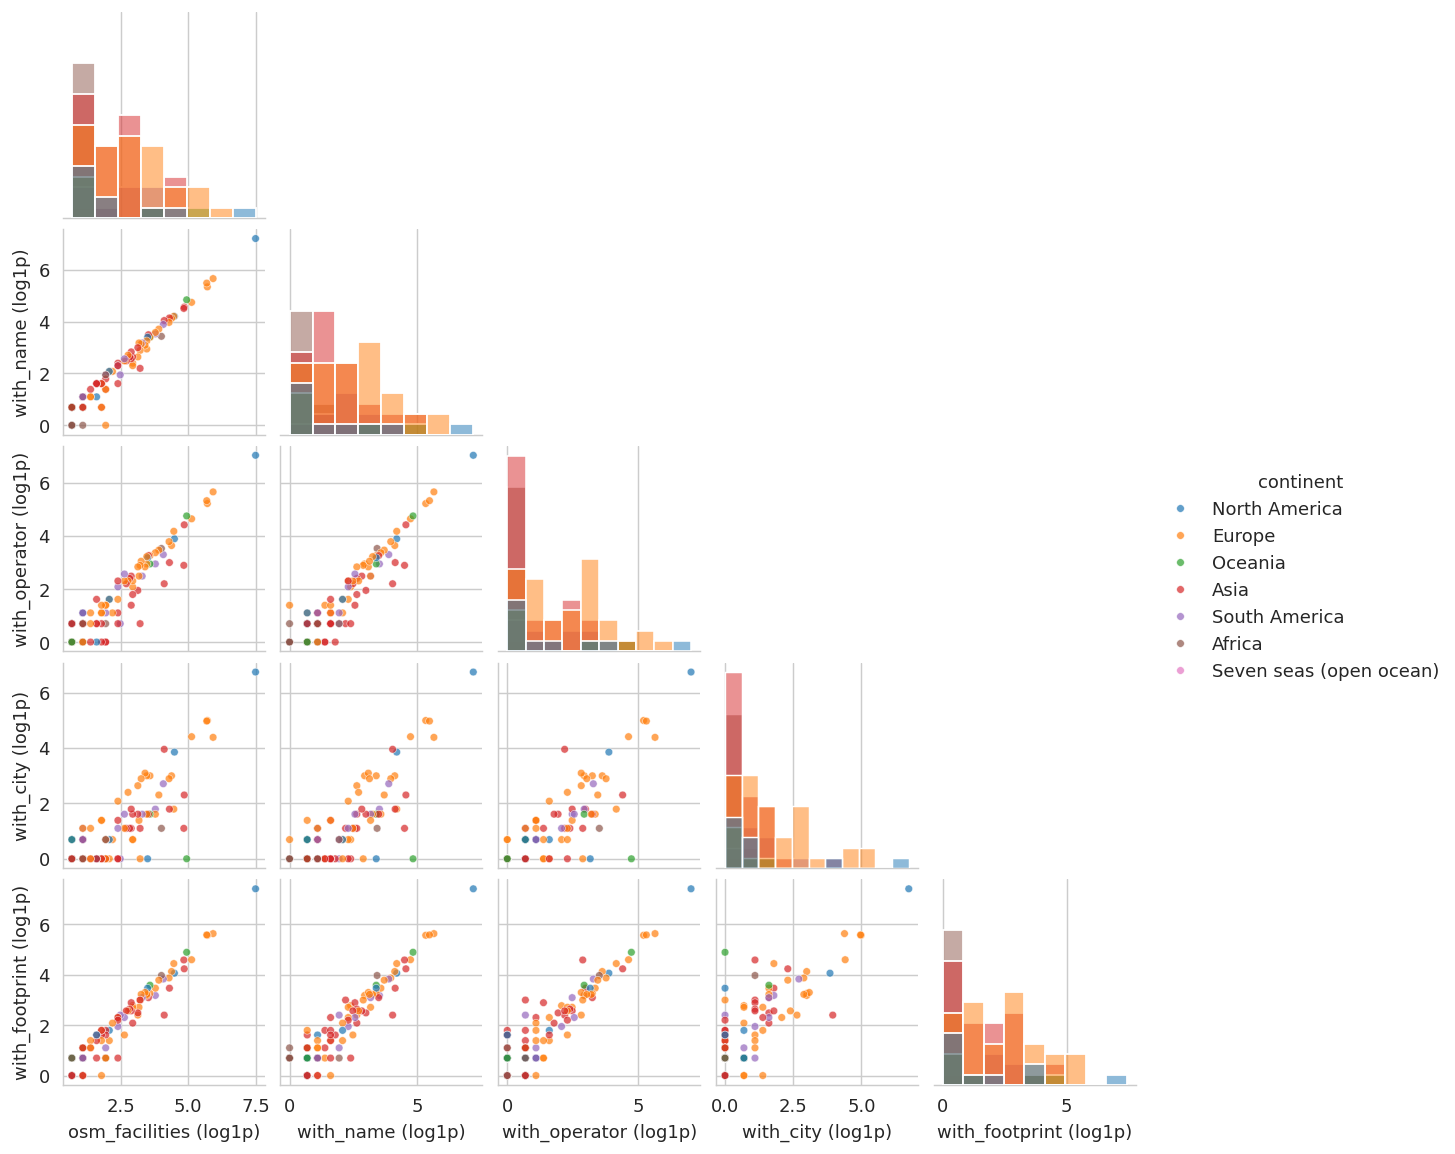

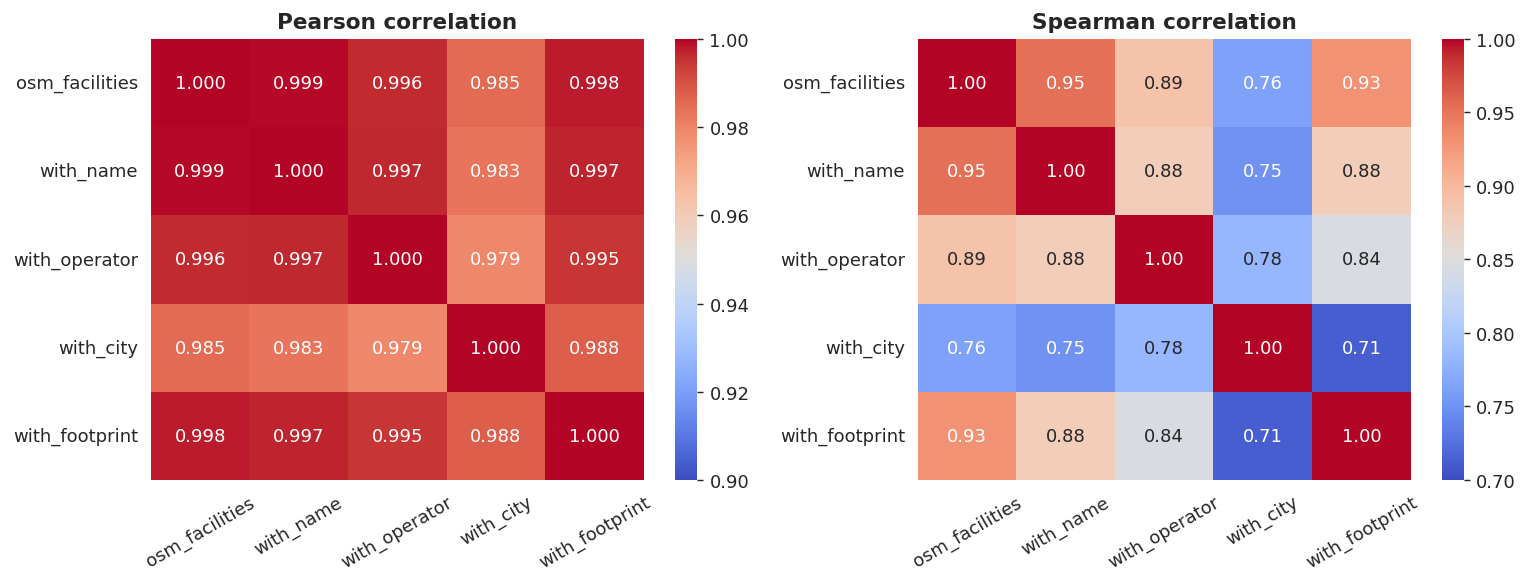

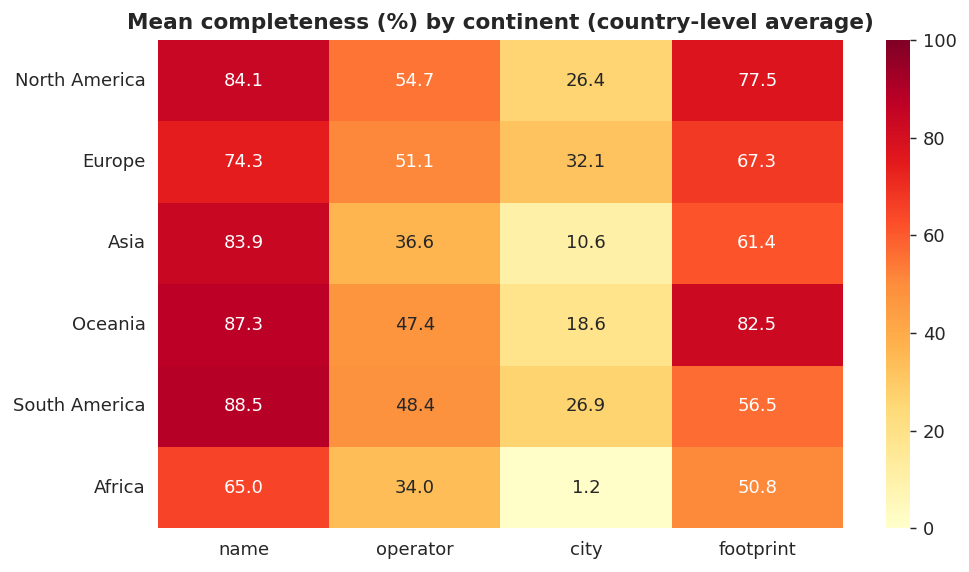

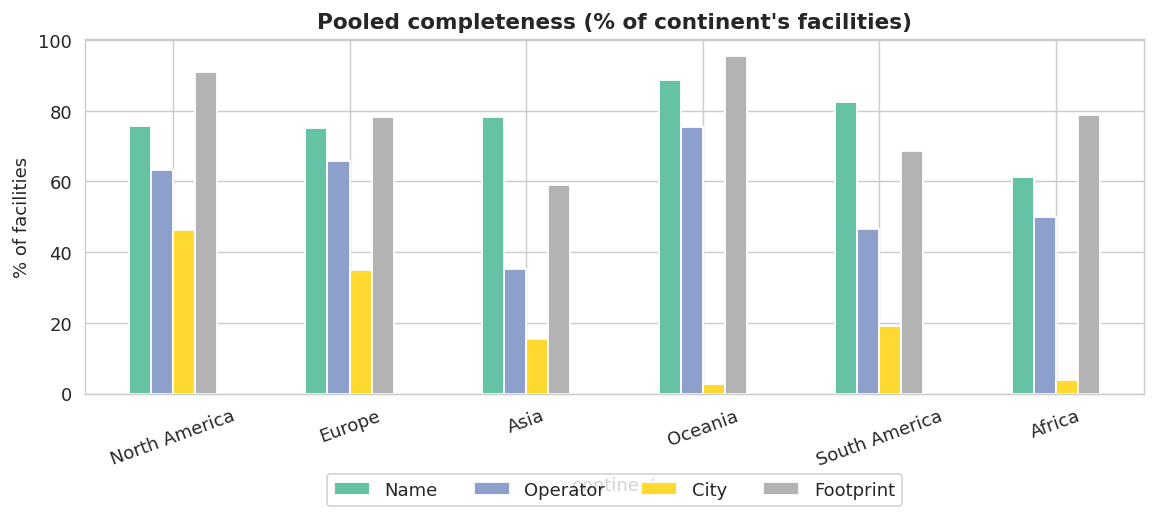

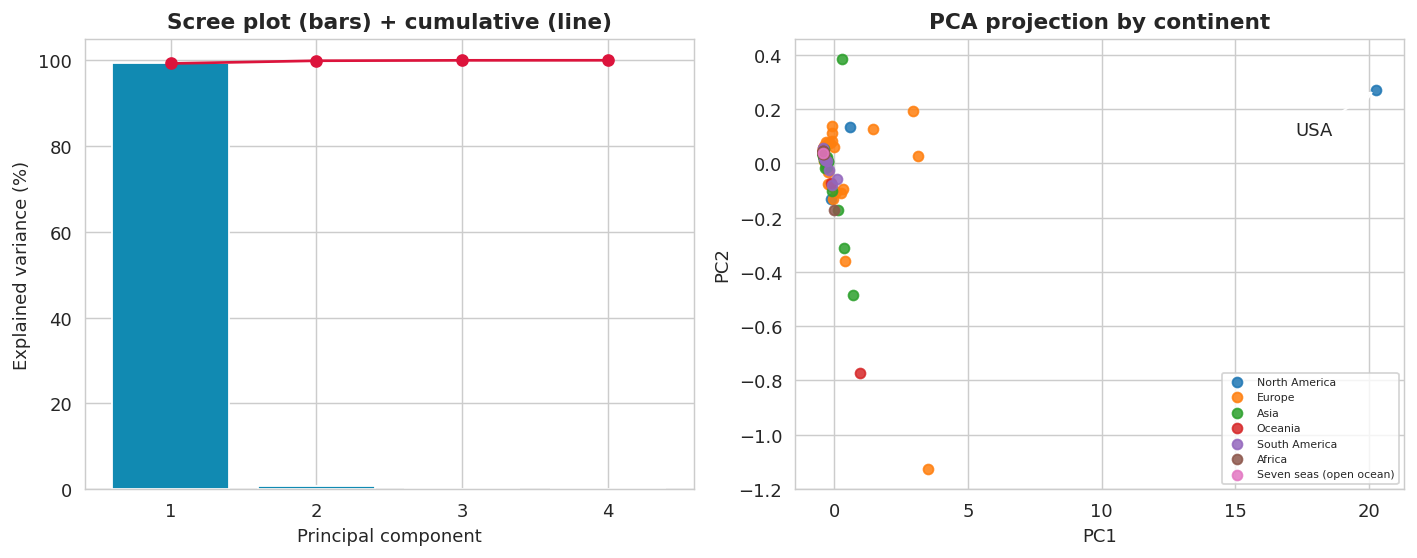

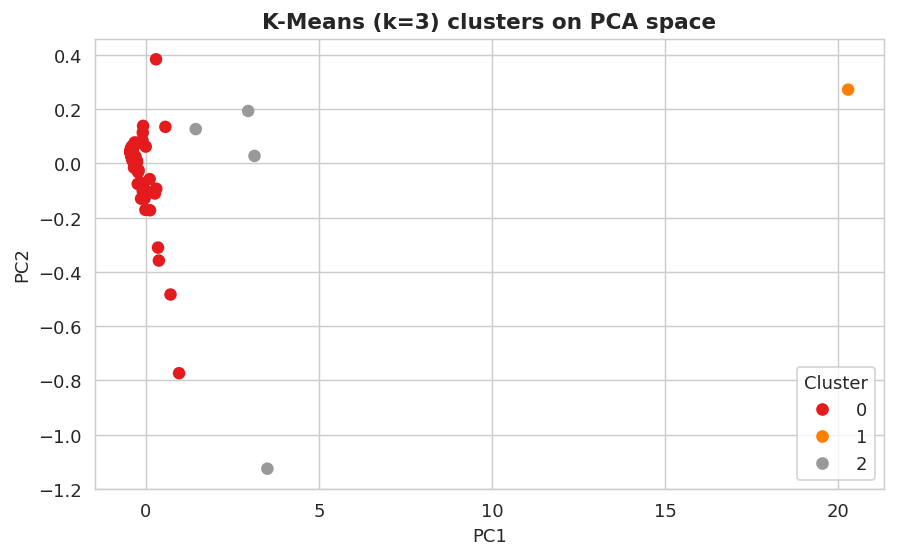

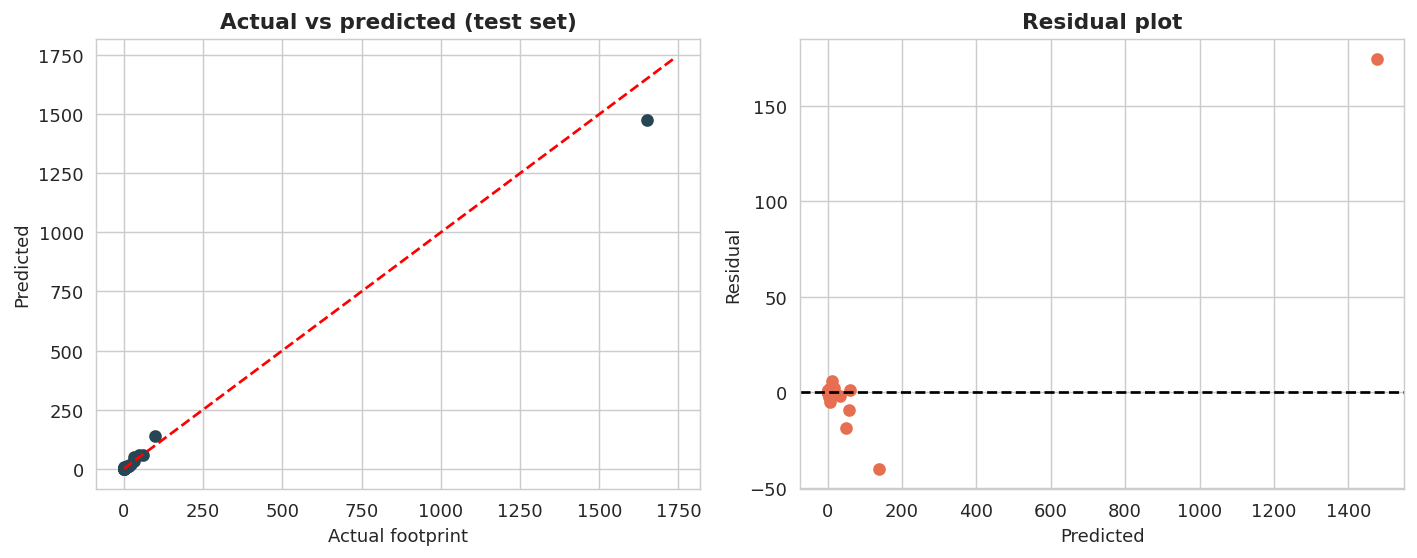

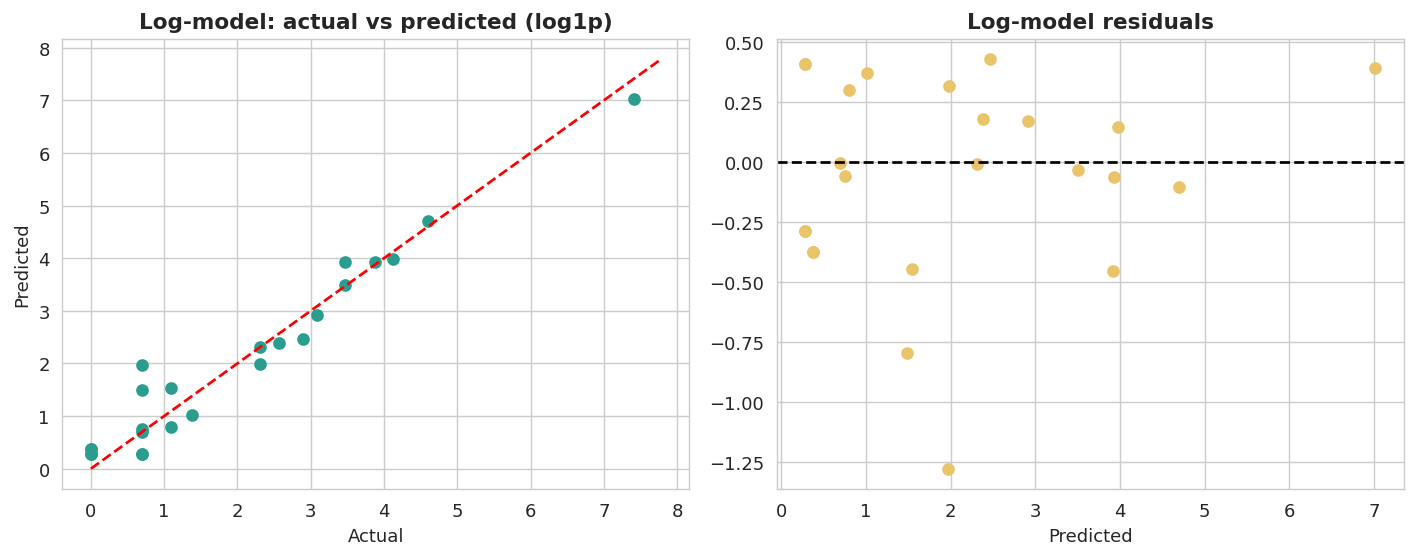

done {'r2': 0.9873803032260823, 'mae': 11.373583793088294, 'rmse': 36.79311423015756, 'coef': {'osm_facilities': 0.7029, 'with_name': -0.0869, 'with_operator': 0.2024, 'with_city': 0.1251}, 'intercept': -0.5680861871886869, 'ntr': 92, 'nte': 24, 'test_has_us': True, 'train_r2': 0.9780195668349841} {'r2': [0.987, 0.873, 0.912, 0.34, 0.953], 'mae': [11.37, 6.69, 9.08, 2.08, 6.23]} {'r2_log': 0.9466673857577602, 'mae_orig': 25.237919883580943, 'rmse_orig': 109.3312326051946, 'cv_r2': [0.947, 0.844, 0.924, 0.73, 0.942]}


In [6]:
lg = np.log1p(df[num]).add_suffix(" (log1p)"); lg["continent"] = df.continent
sns.pairplot(lg, hue="continent", corner=True, diag_kind="hist", plot_kws=dict(s=18, alpha=.7), height=1.8); plt.savefig(FIG + "21_pairplot.png", bbox_inches="tight", dpi=110); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
pc = df[num].corr("pearson"); scr = df[num].corr("spearman")
sns.heatmap(pc, annot=True, fmt=".3f", cmap="coolwarm", vmin=.9, vmax=1, ax=ax[0]); ax[0].set_title("Pearson correlation")
sns.heatmap(scr, annot=True, fmt=".2f", cmap="coolwarm", vmin=.7, vmax=1, ax=ax[1]); ax[1].set_title("Spearman correlation")
for a in ax: a.tick_params(axis="x", rotation=30)
save("22_heatmaps.png"); R["pearson_mat"] = pc.round(3).to_dict(); R["spearman_mat"] = scr.round(3).to_dict()
pct = ["with_name_pct", "with_operator_pct", "with_city_pct", "with_footprint_pct"]
gm = df.groupby("continent")[pct].mean().loc[order]; R["pct_mean"] = gm.round(1).reset_index().to_dict("records")
fig, ax = plt.subplots(figsize=(8, 4.5)); sns.heatmap(gm.drop("Seven seas (open ocean)"), annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, vmin=0, vmax=100); ax.set_title("Mean completeness (%) by continent (country-level average)"); ax.set_ylabel(""); ax.set_xticklabels([t.get_text().replace("with_", "").replace("_pct", "") for t in ax.get_xticklabels()]); save("23_completeness_heatmap.png")
cm = cont[["name_pct", "operator_pct", "city_pct", "footprint_pct"]]
fig, ax = plt.subplots(figsize=(9, 4.2)); cm.drop("Seven seas (open ocean)").plot(kind="bar", ax=ax, colormap="Set2"); ax.set_ylabel("% of facilities"); ax.set_title("Pooled completeness (% of continent's facilities)"); ax.tick_params(axis="x", rotation=20); ax.legend(["Name", "Operator", "City", "Footprint"], ncol=4, loc="upper center", bbox_to_anchor=(.5, -.2)); save("24_completeness_bar.png")

feat = ["osm_facilities", "with_name", "with_operator", "with_city"]
Xs = StandardScaler().fit_transform(df[feat]); pca = PCA().fit(Xs); Z = PCA(n_components=2).fit_transform(Xs)
R["pca"] = {"evr": pca.explained_variance_ratio_.tolist(), "load": dict(zip(feat, pca.components_[0].round(3).tolist())), "load2": dict(zip(feat, pca.components_[1].round(3).tolist()))}
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].bar(range(1, 5), pca.explained_variance_ratio_ * 100, color="#118ab2"); ax[0].plot(range(1, 5), np.cumsum(pca.explained_variance_ratio_) * 100, "o-", color="crimson"); ax[0].set_xlabel("Principal component"); ax[0].set_ylabel("Explained variance (%)"); ax[0].set_title("Scree plot (bars) + cumulative (line)"); ax[0].set_xticks(range(1, 5))
for c in order: m = (df.continent == c).values; ax[1].scatter(Z[m, 0], Z[m, 1], label=c, s=30, color=pal[c], alpha=.85)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2"); ax[1].set_title("PCA projection by continent"); ax[1].legend(fontsize=6)
ax[1].annotate("USA", Z[(df.country_iso2 == "US").values][0], xytext=(-45, -25), textcoords="offset points", arrowprops=dict(arrowstyle="->")); save("25_pca.png")
km = KMeans(3, n_init=10, random_state=42).fit(Z); df["cluster"] = km.labels_
R["kmeans"] = df.groupby("cluster").agg(n=("country", "size"), mean_fac=("osm_facilities", "mean")).round(1).reset_index().to_dict("records")
R["kmeans_members"] = {int(k): df[df.cluster == k].nlargest(4, "osm_facilities").country.tolist() for k in range(3)}
fig, ax = plt.subplots(figsize=(7, 4.4)); sc = ax.scatter(Z[:, 0], Z[:, 1], c=km.labels_, cmap="Set1", s=35); ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("K-Means (k=3) clusters on PCA space"); ax.legend(*sc.legend_elements(), title="Cluster"); save("26_kmeans.png")

yv = df.with_footprint; X = df[feat]
Xtr, Xte, ytr, yte = train_test_split(X, yv, test_size=.2, random_state=42)
lr = LinearRegression().fit(Xtr, ytr); pr_ = lr.predict(Xte)
R["model"] = {"r2": r2_score(yte, pr_), "mae": mean_absolute_error(yte, pr_), "rmse": float(np.sqrt(mean_squared_error(yte, pr_))), "coef": dict(zip(feat, lr.coef_.round(4).tolist())), "intercept": float(lr.intercept_),
              "ntr": len(Xtr), "nte": len(Xte), "test_has_us": bool(df.loc[Xte.index, "country_iso2"].eq("US").any()), "train_r2": lr.score(Xtr, ytr)}
kf = KFold(5, shuffle=True, random_state=42)
R["cv"] = {"r2": cross_val_score(LinearRegression(), X, yv, cv=kf, scoring="r2").round(3).tolist(), "mae": (-cross_val_score(LinearRegression(), X, yv, cv=kf, scoring="neg_mean_absolute_error")).round(2).tolist()}
Xl, yl = np.log1p(X), np.log1p(yv); Xltr, Xlte, yltr, ylte = train_test_split(Xl, yl, test_size=.2, random_state=42)
lm = LinearRegression().fit(Xltr, yltr); pl = lm.predict(Xlte)
R["model_log"] = {"r2_log": r2_score(ylte, pl), "mae_orig": mean_absolute_error(np.expm1(ylte), np.expm1(pl)), "rmse_orig": float(np.sqrt(mean_squared_error(np.expm1(ylte), np.expm1(pl)))),
                  "cv_r2": cross_val_score(LinearRegression(), Xl, yl, cv=kf, scoring="r2").round(3).tolist()}
rg = Ridge(alpha=1.0).fit(Xtr, ytr); R["model_ridge"] = {"r2": r2_score(yte, rg.predict(Xte)), "mae": mean_absolute_error(yte, rg.predict(Xte))}
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].scatter(yte, pr_, color="#264653"); lim = [0, max(yte.max(), pr_.max()) * 1.05]; ax[0].plot(lim, lim, "r--"); ax[0].set_xlabel("Actual footprint"); ax[0].set_ylabel("Predicted"); ax[0].set_title("Actual vs predicted (test set)")
ax[1].scatter(pr_, yte - pr_, color="#e76f51"); ax[1].axhline(0, ls="--", color="k"); ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Residual"); ax[1].set_title("Residual plot")
save("27_regression.png")
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].scatter(ylte, pl, color="#2a9d8f"); l2 = [0, ylte.max() * 1.05]; ax[0].plot(l2, l2, "r--"); ax[0].set_title("Log-model: actual vs predicted (log1p)"); ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted")
ax[1].scatter(pl, ylte - pl, color="#e9c46a"); ax[1].axhline(0, ls="--", color="k"); ax[1].set_title("Log-model residuals"); ax[1].set_xlabel("Predicted")
save("28_log_regression.png")
R["us_pred"] = float(lr.predict(df.loc[df.country_iso2 == "US", feat])[0])
R["best_pct"] = df[df.osm_facilities >= 20].nlargest(5, "with_footprint_pct")[["country", "osm_facilities", "with_footprint_pct"]].round(1).to_dict("records")
R["worst_city"] = df[df.osm_facilities >= 20].nsmallest(5, "with_city_pct")[["country", "osm_facilities", "with_city_pct"]].round(1).to_dict("records")
R["india_rank"] = int(df.osm_facilities.rank(ascending=False, method="min")[df.country == "India"].iloc[0])
df.to_csv("data/osm_facilities_clean.csv", index=False)
json.dump(R, open("results.json", "w"), indent=1, default=lambda o: float(o) if isinstance(o, (np.floating, np.integer)) else str(o))
print("done", R["model"], R["cv"], R["model_log"])